In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from walking_verify import *

In [52]:
df = pd.read_csv('/mnt/sdb/arafat/6mw/csv_raw2/M16_2016_2320.csv')
df.head()

,Timestamp,X,Y,Z
0,1.472572e+09,0.105572,0.275660,0.401760
1,1.472572e+09,-0.246334,0.073314,0.894428
2,1.472572e+09,-0.442815,-0.692082,0.480938
3,1.472572e+09,0.258064,-2.475073,-1.601173
4,1.472572e+09,0.730205,-1.642229,0.269795


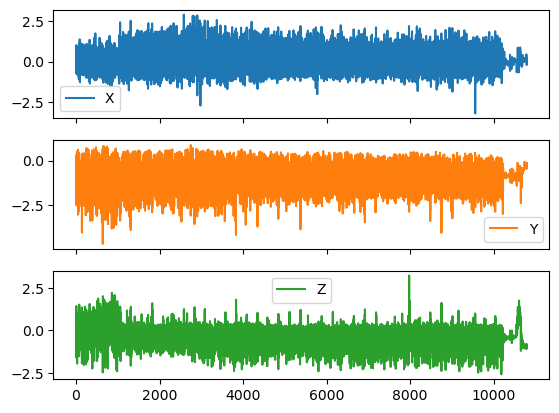

In [53]:
df[['X', 'Y', 'Z']].plot(subplots=True)
plt.show()


In [54]:
summary_df = verify_walking_segment_df(df)
summary_df

,metric,value
0,is_walking,True
1,n_samples,10801
2,fs_est,30.000029
3,duration_s,360.0
4,dominant_freq_hz,2.500002
5,cadence_steps_per_min,150.000143
6,cadence_from_peaks_spm,150.000054
7,median_inter_peak_s,0.4
8,cadence_relative_diff,0.000001
9,n_peaks,890


In [40]:
from pathlib import Path

folder = Path("/mnt/sdb/arafat/6mw/csv_raw2")
csv_paths = sorted(folder.glob("*.csv"))

for path in csv_paths:
    df = pd.read_csv(path)
    out = verify_walking_segment_df(df)
    is_walk = out.set_index("metric").loc["is_walking", "value"]
    if not bool(is_walk):
        print(path)

/mnt/sdb/arafat/6mw/csv_raw2/C70_2017_2113.csv
/mnt/sdb/arafat/6mw/csv_raw2/M23_2018_1613.csv


In [41]:
import re

folder = Path("/mnt/sdb/arafat/6mw/walking_bouts/C01_OPT")
pat = re.compile(r"bout_(\d+)_(\d+)s\.csv$", re.I)
longest_path = max(
    ((int(m.group(2)), p) for p in folder.glob("bout_*_*s.csv") if (m := pat.match(p.name))),
    key=lambda t: t[0],
)[1]
print(longest_path)
df = pd.read_csv(longest_path)
df.head()

/mnt/sdb/arafat/6mw/walking_bouts/C01_OPT/bout_006_2460s.csv


,Timestamp,X,Y,Z
0,1.466348e+09,0.114370,-0.953079,0.085044
1,1.466348e+09,0.111437,-0.953079,0.093842
2,1.466348e+09,0.111437,-0.947214,0.090909
3,1.466348e+09,0.111437,-0.953079,0.085044
4,1.466348e+09,0.123167,-0.947214,0.085044


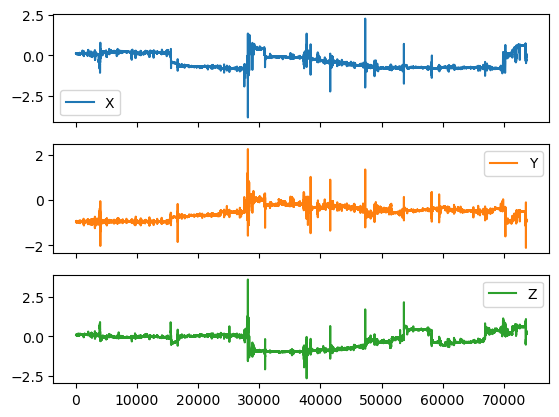

In [42]:
df[['X', 'Y', 'Z']].plot(subplots=True)
plt.show()

In [43]:
summary_df = verify_walking_segment_df(df)
summary_df

,metric,value
0,is_walking,False
1,n_samples,73800
2,fs_est,30.000243
3,duration_s,2459.966667
4,dominant_freq_hz,1.750014
5,cadence_steps_per_min,105.000851
6,cadence_from_peaks_spm,81.818207
7,median_inter_peak_s,0.733333
8,cadence_relative_diff,0.220785
9,n_peaks,506


In [55]:
folder = Path("/mnt/sdb/arafat/6mw/walking_bouts/M16_OPT-2016")
csv_paths = sorted(folder.glob("*.csv"))

for path in csv_paths:
    df = pd.read_csv(path)
    out = verify_walking_segment_df(df)
    is_walk = out.set_index("metric").loc["is_walking", "value"]
    if bool(is_walk):
        print(path)

/mnt/sdb/arafat/6mw/walking_bouts/M16_OPT-2016/bout_001_347s.csv
/mnt/sdb/arafat/6mw/walking_bouts/M16_OPT-2016/bout_002_483s.csv
/mnt/sdb/arafat/6mw/walking_bouts/M16_OPT-2016/bout_003_300s.csv
/mnt/sdb/arafat/6mw/walking_bouts/M16_OPT-2016/bout_004_287s.csv
/mnt/sdb/arafat/6mw/walking_bouts/M16_OPT-2016/bout_006_120s.csv
/mnt/sdb/arafat/6mw/walking_bouts/M16_OPT-2016/bout_007_120s.csv
/mnt/sdb/arafat/6mw/walking_bouts/M16_OPT-2016/bout_008_240s.csv
/mnt/sdb/arafat/6mw/walking_bouts/M16_OPT-2016/bout_009_60s.csv
/mnt/sdb/arafat/6mw/walking_bouts/M16_OPT-2016/bout_010_60s.csv
/mnt/sdb/arafat/6mw/walking_bouts/M16_OPT-2016/bout_011_60s.csv
/mnt/sdb/arafat/6mw/walking_bouts/M16_OPT-2016/bout_014_60s.csv
/mnt/sdb/arafat/6mw/walking_bouts/M16_OPT-2016/bout_015_120s.csv
/mnt/sdb/arafat/6mw/walking_bouts/M16_OPT-2016/bout_017_322s.csv
/mnt/sdb/arafat/6mw/walking_bouts/M16_OPT-2016/bout_018_480s.csv
/mnt/sdb/arafat/6mw/walking_bouts/M16_OPT-2016/bout_019_100s.csv
/mnt/sdb/arafat/6mw/walking_b

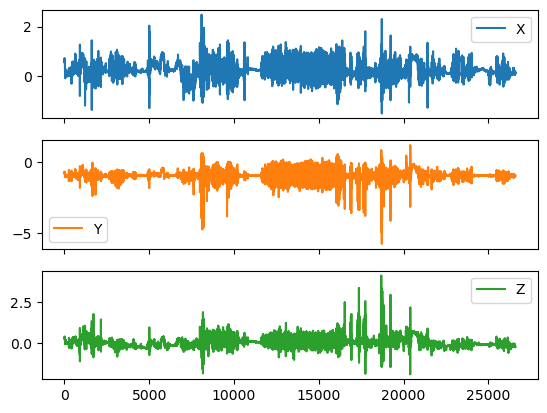

In [58]:
df = pd.read_csv('/mnt/sdb/arafat/6mw/walking_bouts/M16_OPT-2016/bout_367_886s.csv')
df[['X', 'Y', 'Z']].plot(subplots=True)
plt.show()

In [59]:
summary_df = verify_walking_segment_df(df)
summary_df

,metric,value
0,is_walking,True
1,n_samples,26581
2,fs_est,30.303037
3,duration_s,900.0
4,dominant_freq_hz,2.003507
5,cadence_steps_per_min,120.210396
6,cadence_from_peaks_spm,112.570358
7,median_inter_peak_s,0.533
8,cadence_relative_diff,0.063556
9,n_peaks,1143
